# Calculate the spatial gradient of a field on the mesh

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**

### Cylindrical coordinates:

FELiCS is able to handle cartesian and cylindrical coordinates. The cylindrical coordinates in FELiCS are defined with (x, r, theta) where x is analogous to the x in cartesian coordinates, r is the radial component (distance from x-axis) and theta is the azimuthal/angular coordinate which is the angle around the x-axis.
with this coordinate choice our square mesh is basically "rolled" into a cylinder.

=> put equation of gradient with derivative w.r.t. spectral dimension (if any doubt, see https://en.wikipedia.org/wiki/Del_in_cylindrical_and_spherical_coordinates)

=> put validation field creation in its own cell and explain shortly (do we need it here?)

=> put a "TODO" note for later (for after the retreat): for the cylindrical coordinates, if there is a boundary with r=0, this axis is a symmetry boundary, thus there HAS to be either a zero Dirichlet or a zero Neumann condition for "a". We don't set any boundary conditions yet (because the Neumann handling will be implemented after the retreat), but here a Neumann condition should be set for both r and theta

In [2]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cylindrical"
m = 3

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

from FELiCS.SpaceDisc.FEMSpaces import getFELiCSSpace

scalarSpace = getFELiCSSpace(mesh, order=2, dim=1)
vectorSpace = getFELiCSSpace(mesh, order=2, dim=3)

from FELiCS.Fields.Field import Field

phi = Field(scalarSpace, mesh=mesh, m = m)
phi.importH5("function_values_sine")
gradPhiSol = Field(vectorSpace, mesh=mesh)
gradPhiSol.importH5("grad_solution_cylSpectral_m=3")

Info     | FELiCSMesh.py          | __init__                   (line 78  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 86  ) : Mesh contains 513 nodes and 1024 elements


**Step 2: Define the gradient Expression and evaluate it on the Field**

We now want to calculate the gradient of our scalar quantity using the `getGradient()` method of our Field class. This method returns a Field 

In [4]:
##################################
# Tensor Utils stuff in Tensor Utils tutorial
from ufl import TestFunction, dx, conj
from FELiCS.Misc.tensorUtils import iGrad, iConj, iDot, Tensor
import dolfinx.fem

J_hat = mesh.coordinateSystem.J_hat
v = TestFunction(vectorSpace)
v_tens = Tensor(v, CoordSys=mesh.coordinateSystem, hasSpectralDimension=True)
expression = iDot(iGrad(phi.getTensor()), iConj(v_tens)).ufl_tens * J_hat* dx
###################################

gradPhi = phi.getGradientField()

print(sum(gradPhi.getCoefficientArray() - gradPhiSol.getCoefficientArray()))

(-0.19815778791959132+92.17994219903049j)


**Step 3: Postprocessing**

Visualization of the gradients with matplotlib

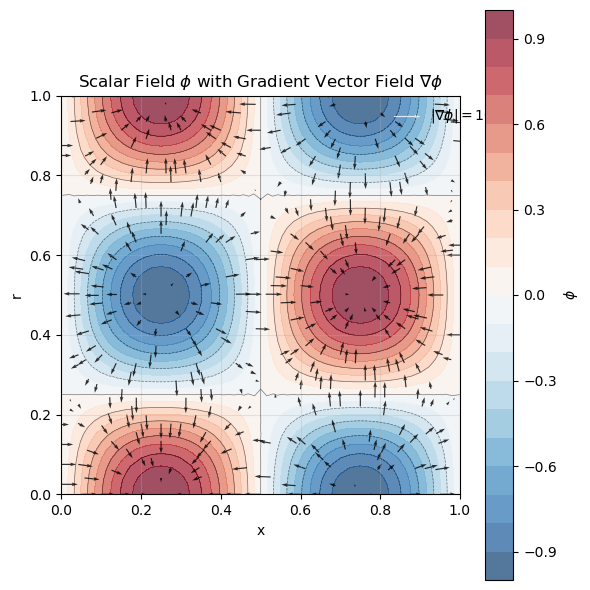

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.tri import Triangulation

# Get DOF coordinates for both scalar and vector spaces
scalar_dof_coords = scalarSpace.tabulate_dof_coordinates()
vector_dof_coords = vectorSpace.tabulate_dof_coordinates()

# Get the field values
phi_values = phi.getCoefficientArray()
gradPhi_x = np.real(gradPhi.getListOfSingleFields()[0].getCoefficientArray())
gradPhi_y = np.real(gradPhi.getListOfSingleFields()[1].getCoefficientArray())


# Extract x and y coordinates
x_scalar = scalar_dof_coords[:, 0]
y_scalar = scalar_dof_coords[:, 1]
x_vector = vector_dof_coords[:, 0]
y_vector = vector_dof_coords[:, 1]

# Extract gradient components (real parts for visualization)
# For vector space with dim=3, we have [grad_x, grad_y, grad_z] components
n_dofs = len(vector_dof_coords)

# Create triangulation for contour plot
triang_scalar = Triangulation(x_scalar, y_scalar)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Create contour plot of phi
contour = ax.tricontourf(triang_scalar, np.real(phi_values), levels=20, cmap='RdBu_r', alpha=0.7)
contour_lines = ax.tricontour(triang_scalar, np.real(phi_values), levels=10, colors='black', alpha=0.5, linewidths=0.5)

# Add colorbar for phi
cbar = plt.colorbar(contour, ax=ax, label=r'$\phi$')

# Add quiver plot of gradient (subsample for clarity)
skip = 5  # Show every 5th vector to avoid overcrowding
quiver = ax.quiver(x_vector[::skip], y_vector[::skip], 
                   gradPhi_x[::skip], gradPhi_y[::skip], 
                   scale=150, alpha=0.8, color='black', width=0.003)

# Add a reference arrow
ax.quiverkey(quiver, 0.9, 0.95, 10, r'$|\nabla\phi| = 10$', 
             labelpos='E', coordinates='axes', color='white')

# Set labels and title
ax.set_xlabel('x')
ax.set_ylabel('r')
ax.set_title(r'Scalar Field $\phi$ with Gradient Vector Field $\nabla\phi$')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()